# eSIM Service - Data Quality & Revenue Overview

Business question: the eSIM service's revenue dropped from January to February 2026. This notebook is step 1 of the investigation:

1. Load the raw data and make sure it is trustworthy enough to analyze.
2. Get a first look at the headline revenue numbers, so the rest of the project has a clear target to explain.

The deep-dive hypothesis testing lives in the next notebooks:
- **01_revenue_drop_diagnosis.ipynb** - why did revenue fall?
- **02_cohort_conversion_analysis.ipynb** - did onboarding/conversion quality change?
- **03_conclusions_and_recommendations.ipynb** - the executive summary.

Data: two synthetic tables, **users** (~26.9k rows) and **orders** (~3.6k rows), covering January 1 – February 28, 2026. See **data/README.md** for the full data dictionary.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.db import get_connection, load_query  # noqa: E402

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
PAID_SOCIAL_COLOR = "#d62728"
OTHER_COLOR = "#4c72b0"

con = get_connection()
print("Connected. Tables loaded:", con.execute("SHOW TABLES").fetchdf()["name"].tolist())

Connected. Tables loaded: ['base_orders', 'orders', 'users']


## 1. First look at the raw tables

In [2]:
users = con.execute("SELECT * FROM users").fetchdf()
orders = con.execute("SELECT * FROM orders").fetchdf()

print(f"users: {users.shape[0]:,} rows x {users.shape[1]} columns")
display(users.head())

print(f"\norders: {orders.shape[0]:,} rows x {orders.shape[1]} columns")
display(orders.head())

users: 26,900 rows x 5 columns


,user_id,registered_date,country,platform,acquisition_channel
0,10001,2026-01-03,Japan,ios,organic
1,10002,2026-01-02,Egypt,ios,organic
2,10003,2026-01-26,Japan,ios,organic
3,10004,2026-01-30,United States,ios,organic
4,10005,2026-01-10,India,ios,organic



orders: 3,618 rows x 8 columns


,order_id,user_id,created_date,country,packet_size_name,price_eur,order_status,platform
0,100001,10005,2026-01-13,India,5 GB,13.0,paid,ios
1,100002,10005,2026-01-23,India,10 GB,19.0,paid,ios
2,100003,10014,2026-01-08,Spain,Unlimited 30 days,55.0,paid,ios
3,100004,10019,2026-01-28,Turkey,Unlimited 7 days,22.0,paid,web
4,100005,10026,2026-01-18,Egypt,3 GB,9.0,paid,ios


## 2. Data quality checks

Before trusting any downstream number, we check the basics: unique keys, missing values, valid date ranges, referential integrity between the two tables, and whether categorical/numeric columns look sane. All checks are defined in [**sql/02_data_quality_checks.sql**](../sql/02_data_quality_checks.sql).

In [3]:
print("Unique keys check (expect duplicate_rows == 0 for both tables):")
display(con.execute(load_query("02_data_quality_checks.sql", "unique_keys")).fetchdf())

print("\nNull check - users (expect all zeros):")
display(con.execute(load_query("02_data_quality_checks.sql", "null_check_users")).fetchdf())

print("\nNull check - orders (expect all zeros):")
display(con.execute(load_query("02_data_quality_checks.sql", "null_check_orders")).fetchdf())

Unique keys check (expect duplicate_rows == 0 for both tables):


,table_name,row_count,unique_ids,duplicate_rows
0,users,26900,26900,0
1,orders,3618,3618,0



Null check - users (expect all zeros):


,null_user_id,null_registered_date,null_country,null_platform,null_acquisition_channel
0,0,0,0,0,0



Null check - orders (expect all zeros):


,null_order_id,null_user_id,null_created_date,null_country,null_packet_size_name,null_price_eur,null_order_status,null_platform
0,0,0,0,0,0,0,0,0


In [4]:
print("Date range check:")
display(con.execute(load_query("02_data_quality_checks.sql", "date_range")).fetchdf())

print("\nReferential integrity check (expect 0 orphan/impossible orders):")
display(con.execute(load_query("02_data_quality_checks.sql", "referential_integrity")).fetchdf())

print("\nPrice sanity check:")
display(con.execute(load_query("02_data_quality_checks.sql", "price_distribution")).fetchdf())

Date range check:


,table_name,min_date,max_date
0,users,2026-01-01,2026-02-28
1,orders,2026-01-01,2026-02-28



Referential integrity check (expect 0 orphan/impossible orders):


,orders_cnt,orders_without_user,orders_before_registration
0,3618,0,0



Price sanity check:


,orders_cnt,non_positive_prices,min_price,max_price,avg_price,median_price
0,3618,0,4.5,55.0,20.65,19.0


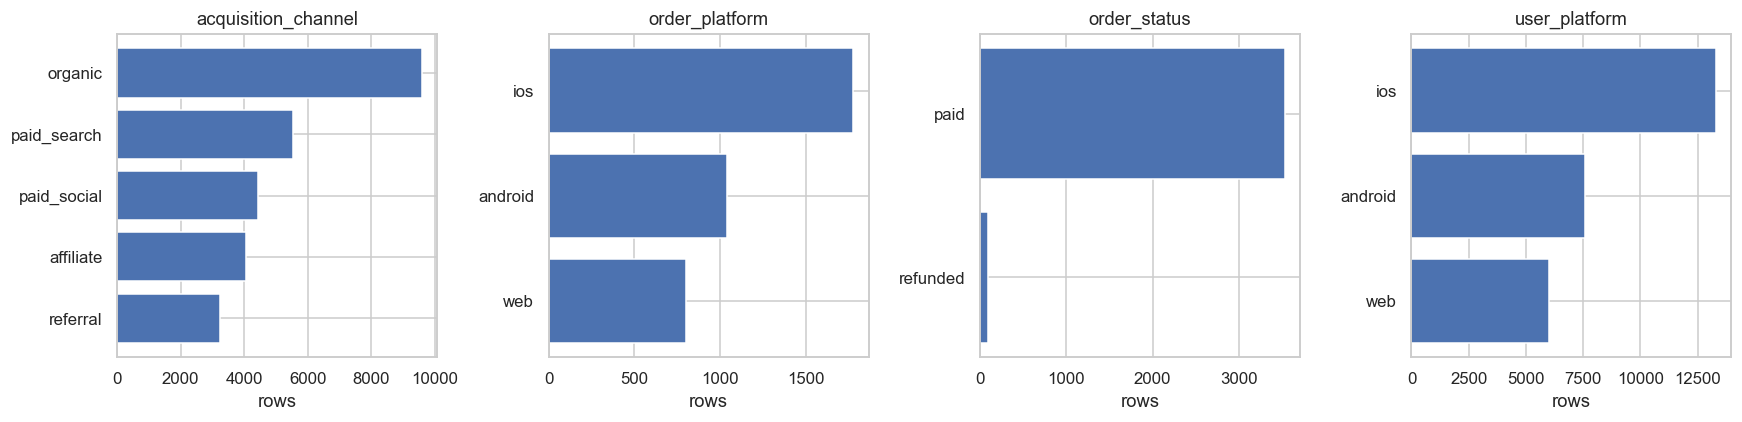

Countries in orders: 14 | Packages: 9


In [5]:
category_values = con.execute(load_query("02_data_quality_checks.sql", "category_values")).fetchdf()

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, dim in zip(axes, category_values["dimension"].unique()):
    subset = category_values[category_values["dimension"] == dim].sort_values("row_count", ascending=True)
    ax.barh(subset["value"], subset["row_count"], color=OTHER_COLOR)
    ax.set_title(dim)
    ax.set_xlabel("rows")
plt.tight_layout()
plt.show()

print(f"Countries in orders: {orders['country'].nunique()} | Packages: {orders['packet_size_name'].nunique()}")

Conclusion - data quality: both tables are clean. No duplicate keys, no missing values, no orders placed before registration or without a matching user, and prices/dates fall within sane ranges. There are a few synthetic-data artifacts worth flagging honestly rather than hiding (e.g. a user's registration country and order country are sometimes identical in a way that looks too clean for real-world roaming behavior) - expected for a generated dataset and not treated as a data quality problem. The data is reliable enough to build the revenue analysis on.

## 3. Headline revenue picture

Now that the data is trusted, let's look at the number we're actually trying to explain.

In [6]:
monthly = con.execute(load_query("03_revenue_drop_hypotheses.sql", "monthly_overview")).fetchdf()
display(monthly)

jan_rev, feb_rev = monthly.loc[0, "revenue_eur"], monthly.loc[1, "revenue_eur"]
change_pct = (feb_rev - jan_rev) / jan_rev * 100
print(f"\nRevenue change Jan -> Feb: {feb_rev - jan_rev:,.1f} EUR ({change_pct:.1f}%)")

,order_month,paid_orders,paying_users,revenue_eur,aov_eur
0,2026-01-01,1790,1660,39119.5,21.85
1,2026-02-01,1739,1610,33827.0,19.45



Revenue change Jan -> Feb: -5,292.5 EUR (-13.5%)


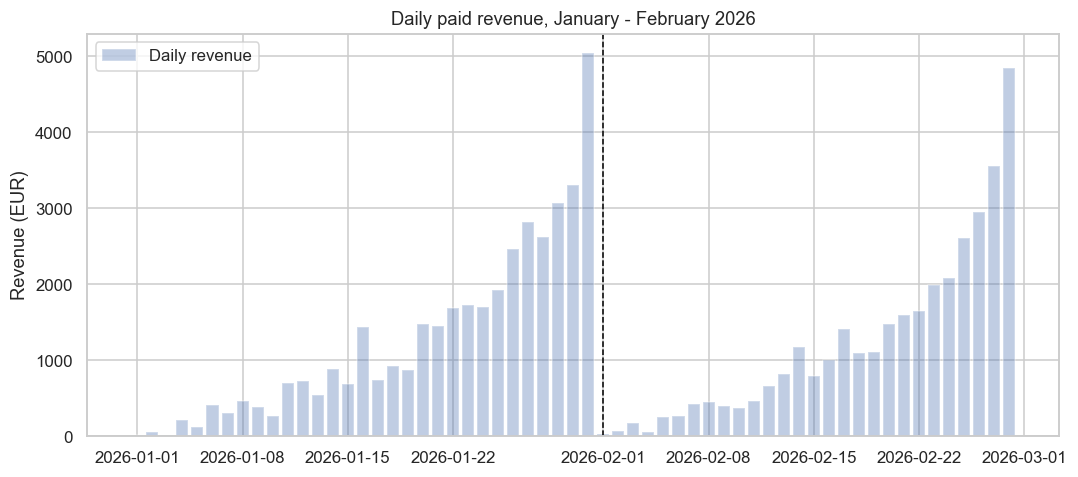

In [8]:
daily_revenue = con.execute(
    """
    SELECT created_date, SUM(price_eur) AS revenue_eur
    FROM base_orders
    WHERE order_status = 'paid'
    GROUP BY created_date
    ORDER BY created_date
    """
).fetchdf()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(daily_revenue["created_date"], daily_revenue["revenue_eur"], color=OTHER_COLOR, alpha=0.35, label="Daily revenue")
ax.axvline(pd.Timestamp("2026-02-01"), color="black", linestyle="--", linewidth=1)
ax.set_title("Daily paid revenue, January - February 2026")
ax.set_ylabel("Revenue (EUR)")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "00_daily_revenue_trend.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

- The data is clean and safe to analyze.
- February revenue was 33,827.0 EUR vs January's 39,119.5 EUR - a drop of -5,292.5 EUR (-13.5%).
- Both months show the same within-month ramp-up shape (low right after the 1st, rising toward month-end) - this looks like an artifact of how the synthetic data was generated rather than a real seasonality effect, so day-level comparisons later in this project are done "day-of-month vs day-of-month" rather than on raw calendar dates.
- There is no sudden one-day cliff - the drop shows up as a lower plateau, which points toward a structural change (mix of customers/channels/products) rather than a single outage or incident.

Next: [**01_revenue_drop_diagnosis.ipynb**](01_revenue_drop_diagnosis.ipynb) tests concrete hypotheses for what caused this.